# AI Model for Heart Disease Prediction

This project builds a machine learning model to predict the likelihood of heart disease using clinical patient data.

The workflow includes:
- Data exploration
- Data preprocessing
- Visualization of key risk factors
- Machine learning model training
- Model evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [3]:
data = pd.read_csv("heart.csv", header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
data.columns = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal","target"]
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [6]:
data = data.replace("?", np.nan)
data = data.apply(pd.to_numeric)
data = data.dropna()

In [7]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
data["target"] = data["target"].apply(lambda x: 1 if x > 0 else 0)

In [9]:
data["target"].value_counts()

target
0    160
1    137
Name: count, dtype: int64

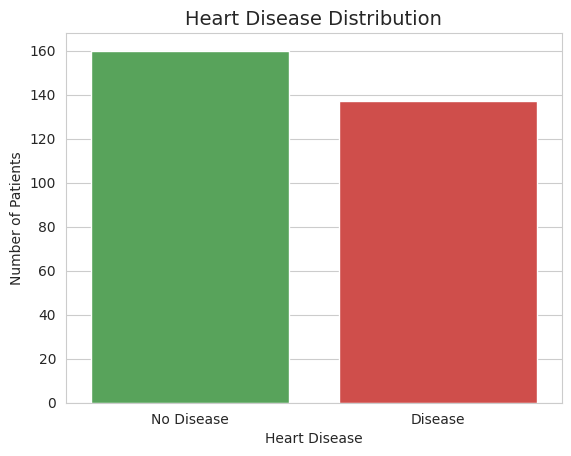

In [10]:
sns.countplot(
    x="target",
    data=data,
    hue="target",
    palette=["#4CAF50", "#E53935"],
    legend=False)

plt.title("Heart Disease Distribution", fontsize=14)
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.xticks([0,1], ["No Disease","Disease"])

plt.savefig("disease_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [11]:
X = data.drop("target", axis=1)
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [13]:
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.8833333333333333


In [14]:
feature_importance = pd.Series(model.feature_importances_,index=X.columns)

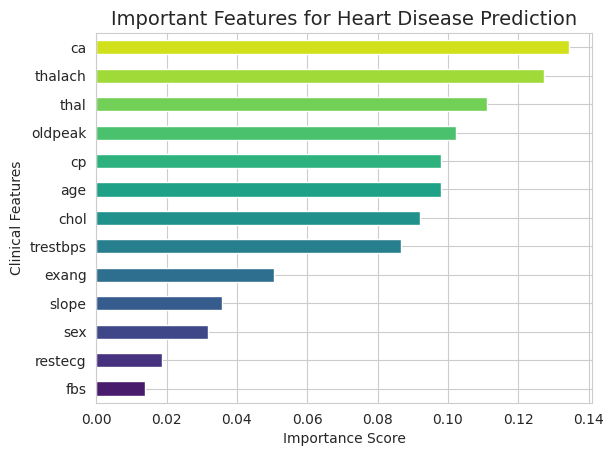

In [15]:
colors = sns.color_palette("viridis", len(feature_importance))

feature_importance.sort_values(ascending=True).plot(
    kind="barh",
    color=colors)

plt.title("Important Features for Heart Disease Prediction", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Clinical Features")

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

## Conclusion

A Random Forest machine learning model was trained to predict the likelihood of heart disease using clinical patient data.

The model achieved an accuracy of **88.33%**, demonstrating strong predictive performance on the test dataset.

Feature importance analysis revealed that the most influential predictors were:

- **Number of major vessels (ca)**
- **Maximum heart rate achieved (thalach)**
- **Thalassemia type (thal)**
- **ST depression induced by exercise (oldpeak)**

These findings highlight how specific cardiovascular indicators can significantly influence heart disease prediction.

This project illustrates how machine learning techniques can be applied to healthcare data to assist in identifying patients at higher risk of cardiovascular disease and potentially support early clinical decision-making.